# Quickstart: Spectroscopic SED Fitting

Fit a galaxy spectrum with EVI (Expansion-point Variational Inference).

- 200 spectral pixels, SNR=30
- Smooth double-power-law SFH (D=7)
- Full posterior in ~12 seconds

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

from diffsed import (
    Fitter,
    Fixed,
    Model,
    ParamSpec,
    Uniform,
    load_filter_set,
    load_ssp_data,
)

## 1. Model Setup

In [2]:
ssp_data = load_ssp_data(
    "../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
)
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])

spec = ParamSpec(
    sfh_dpl_alpha=Uniform(0.5, 3.0),
    sfh_dpl_beta=Uniform(0.5, 3.0),
    sfh_dpl_tau_gyr=Uniform(0.5, 13.0),
    sfh_dpl_log_peak_sfr=Uniform(-1.0, 2.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
)

# Precompute SSP interpolation for the observed wavelength grid (~8x speedup)
wave_obs = np.linspace(3800, 9200, 200).astype(np.float64)
model = Model(spec, ssp_data, filters=filters).precompute_spectroscopy(wave_obs)

print(f"Free parameters: {spec.free_params}")
print(f"D = {len(spec.free_params)}, n_pixels = {len(wave_obs)}")

W0320 22:23:32.941315 13645549 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Free parameters: ['dust_tau_bc', 'dust_tau_diff', 'met_logzsol', 'sfh_dpl_alpha', 'sfh_dpl_beta', 'sfh_dpl_log_peak_sfr', 'sfh_dpl_tau_gyr']
D = 7, n_pixels = 200


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_48933/2530006250.py:20: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model = Model(spec, ssp_data, filters=filters).precompute_spectroscopy(wave_obs)


## 2. Mock Spectrum

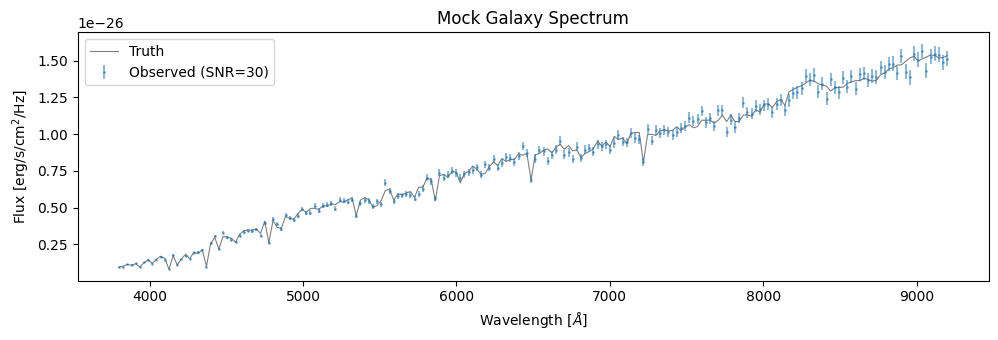

In [3]:
key = jax.random.PRNGKey(42)

true_params = spec.sample(key)
true_params.update(
    sfh_dpl_alpha=1.0,
    sfh_dpl_beta=1.5,
    sfh_dpl_tau_gyr=8.0,
    sfh_dpl_log_peak_sfr=1.5,
    met_logzsol=-0.3,
    dust_tau_bc=0.5,
    dust_tau_diff=0.3,
)

mock = model.mock_spectrum(true_params, wave_obs, snr=30.0, key=key)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(wave_obs, mock.flux_true, "k-", lw=0.8, alpha=0.5, label="Truth")
ax.errorbar(
    wave_obs,
    mock.flux_obs,
    yerr=mock.noise,
    fmt=".",
    ms=2,
    color="C0",
    alpha=0.5,
    label="Observed (SNR=30)",
)
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"Flux [erg/s/cm$^2$/Hz]")
ax.set_title("Mock Galaxy Spectrum")
ax.legend()
plt.tight_layout()
plt.show()

## 3. EVI Inference

EVI runs a fully JIT-compiled geoVI optimization loop, then draws
posterior samples via JIT-compiled conjugate gradient.
With spectroscopy precomputation, the forward model is ~8x faster.

In [4]:
import time

fitter = Fitter(model, mock.flux_obs, mock.noise, data_type="spectroscopy")

key_fit, key = jax.random.split(key)
t0 = time.perf_counter()
result = fitter.run("native_evi", n_posterior_samples=500, n_seeds=3, key=key_fit)
dt = time.perf_counter() - t0

pred = model.predict_spectrum(result.params)
chi2_dof = float(jnp.sum(((mock.flux_obs - pred) / mock.noise) ** 2)) / len(wave_obs)
print(f"Time: {dt:.1f}s | chi2/dof: {chi2_dof:.2f} | Samples: {result.diagnostics['n_samples']}")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


MGVI (JIT): 7 params, 200 data points, 50 iterations, 3 samples/iter, 3 seeds


  Seed 1/3: H=109.2, 11 iters


  Seed 2/3: H=110.5, 18 iters


  Seed 3/3: H=151.2, 13 iters
  Drawing 500 posterior samples (JIT CG)...


<local>/Projects/diffsed/src/diffsed/fitter.py:1901: UserWarning: Seeds disagree: H = 123.6 ± 19.5 (CV=16%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_evi_jit(


  EVI (JIT) complete in 11.0s, 11/50 iterations, 500 posterior samples
Time: 19.5s | chi2/dof: 1.47 | Samples: 500


## 4. Spectral Fit

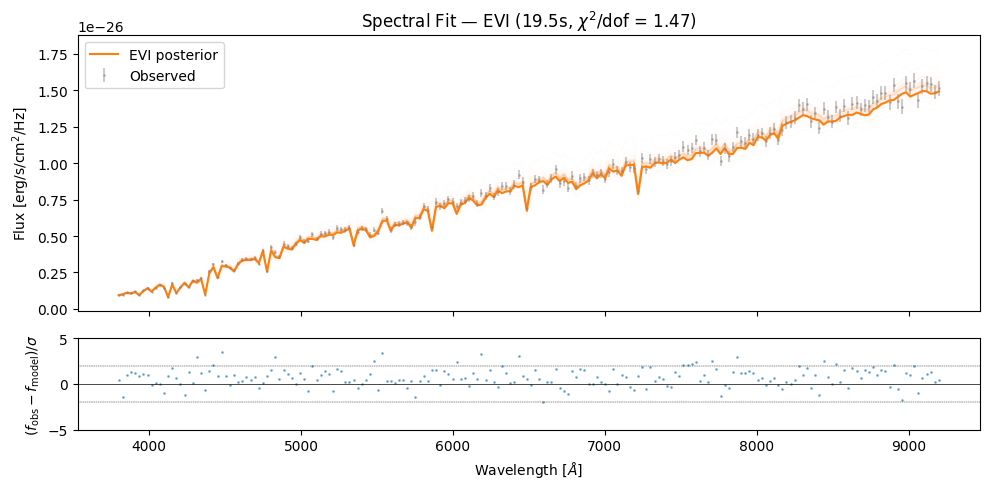

In [5]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 5), gridspec_kw={"height_ratios": [3, 1]}, sharex=True
)

ax1.errorbar(
    wave_obs,
    mock.flux_obs,
    yerr=mock.noise,
    fmt=".",
    ms=2,
    color="gray",
    alpha=0.4,
    label="Observed",
)

# Draw posterior spectra
n_draw = min(50, result.diagnostics["n_samples"])
for i in range(n_draw):
    params_i = dict(true_params)
    for name in spec.free_params:
        if name in result.samples:
            params_i[name] = float(result.samples[name][i])
    pred_i = model.predict_spectrum(params_i)
    ax1.plot(wave_obs, pred_i, "-", color="C1", alpha=0.04, lw=0.5)

ax1.plot(wave_obs, pred, "-", color="C1", lw=1.5, label="EVI posterior")
ax1.set_ylabel(r"Flux [erg/s/cm$^2$/Hz]")
ax1.legend()
ax1.set_title(f"Spectral Fit — EVI ({dt:.1f}s, $\\chi^2$/dof = {chi2_dof:.2f})")

residuals = (mock.flux_obs - pred) / mock.noise
ax2.plot(wave_obs, residuals, ".", ms=2, color="C0", alpha=0.5)
ax2.axhline(0, color="k", lw=0.5)
ax2.axhline(2, color="k", lw=0.3, ls="--")
ax2.axhline(-2, color="k", lw=0.3, ls="--")
ax2.set_ylabel(r"$(f_{\rm obs} - f_{\rm model})/\sigma$")
ax2.set_xlabel(r"Wavelength [$\AA$]")
ax2.set_ylim(-5, 5)

plt.tight_layout()
plt.show()

## 5. Corner Plot

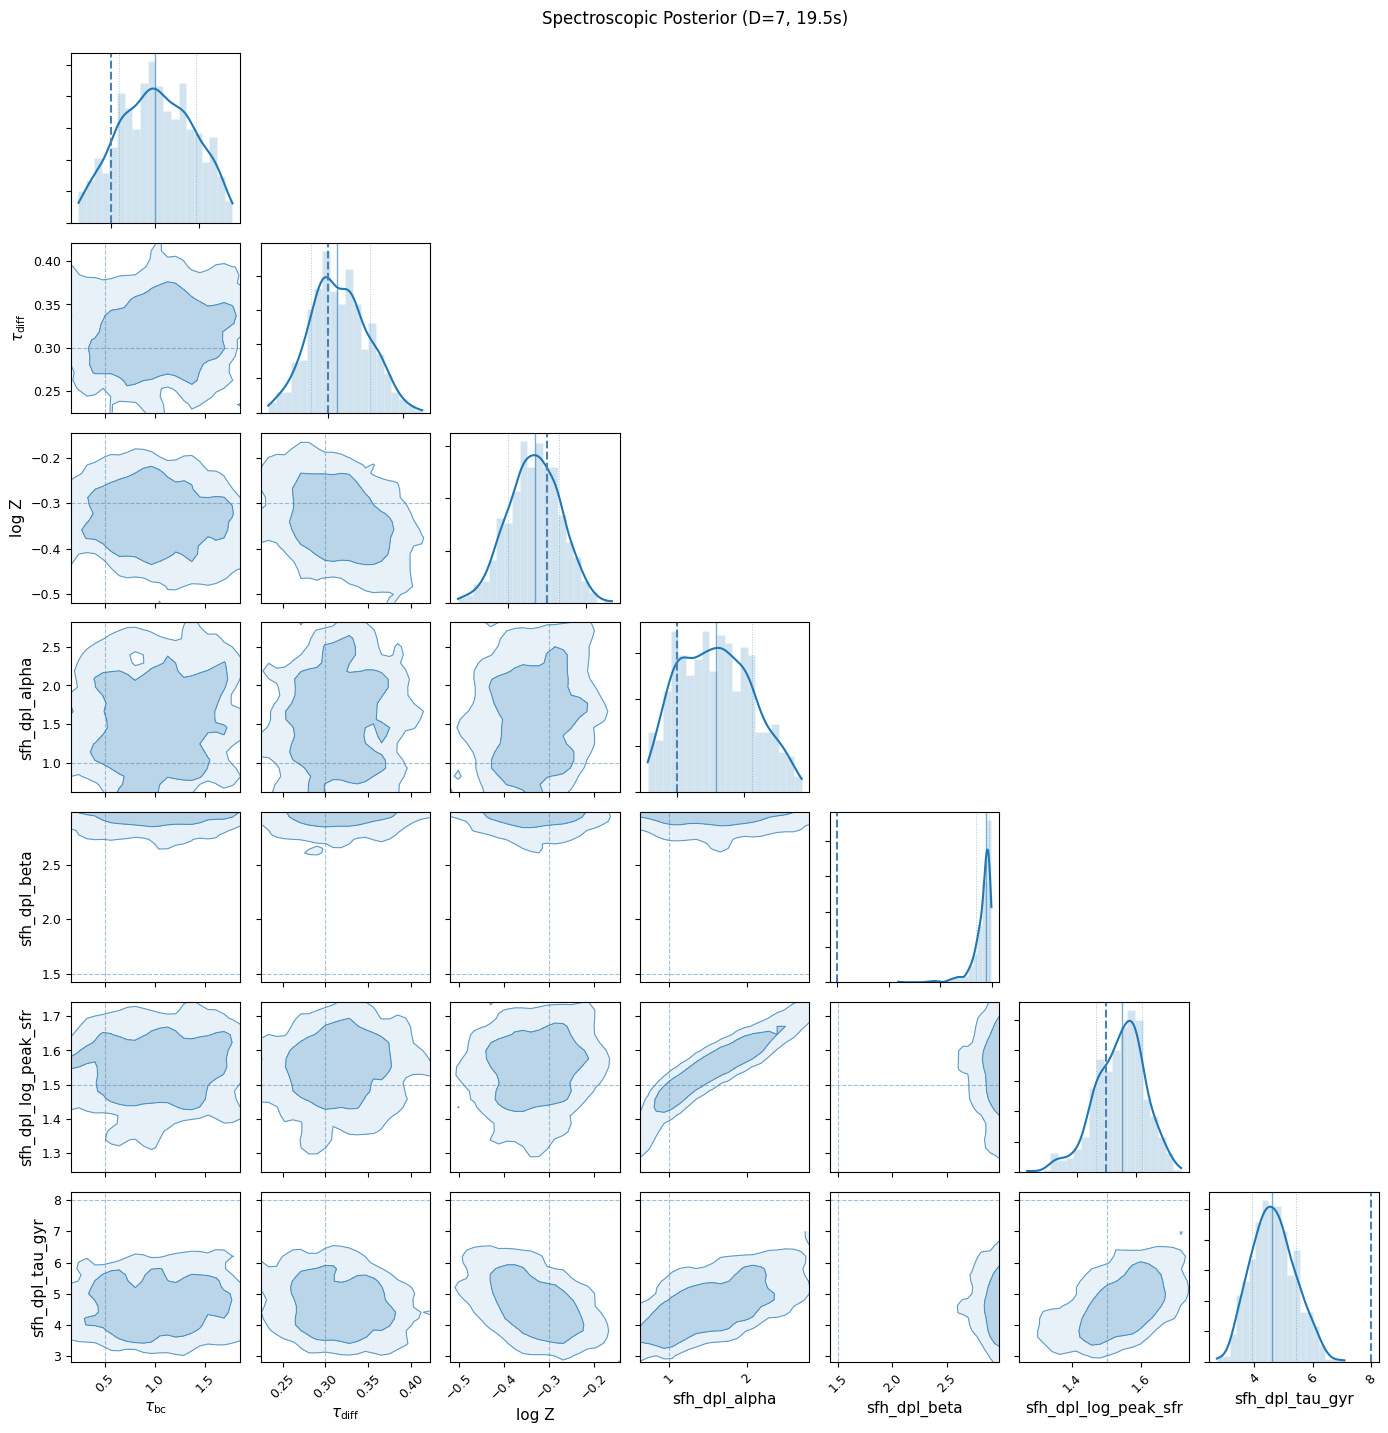

In [6]:
from diffsed.plotting import safe_corner

truths = {k: float(true_params[k]) for k in spec.free_params}
fig = safe_corner(result, params=spec.free_params, truths=truths)
if fig is not None:
    fig.suptitle(
        f"Spectroscopic Posterior (D={len(spec.free_params)}, {dt:.1f}s)", y=1.02
    )
plt.show()

## 6. Parameter Recovery

In [7]:
print(f"{'Parameter':>25}  {'Truth':>7}  {'Median':>7}  {'Std':>7}  {'Bias(σ)':>8}")
print("-" * 65)
for name in spec.free_params:
    truth = float(true_params[name])
    if name in result.samples:
        samples = np.array(result.samples[name])
        med = np.median(samples)
        std = np.std(samples)
        bias = (med - truth) / std if std > 0 else 0
        print(f"{name:>25}  {truth:7.2f}  {med:7.2f}  {std:7.2f}  {bias:+8.2f}")

                Parameter    Truth   Median      Std   Bias(σ)
-----------------------------------------------------------------
              dust_tau_bc     0.50     1.00     0.41     +1.21
            dust_tau_diff     0.30     0.31     0.04     +0.32
              met_logzsol    -0.30    -0.33     0.07     -0.50
            sfh_dpl_alpha     1.00     1.58     0.53     +1.09
             sfh_dpl_beta     1.50     2.94     0.09    +15.21
     sfh_dpl_log_peak_sfr     1.50     1.55     0.08     +0.65
          sfh_dpl_tau_gyr     8.00     4.62     0.74     -4.56
